# Table 1 — Heston Attack Robustness

Replicates **Table 1** from He, Sutter & Gonon (2025): *Robustness of the classical deep hedging strategy under different attack methods and magnitudes* for the Heston model.

**Setup**: fresh test paths (seed=20, M paths), four trained networks (ES_α for α ∈ {0.5, 0.75, 0.95, 0.99}), four attack variants:

| Column | Method | Perturbed assets |
|--------|--------|------------------|
| WPGD-S | Wasserstein-q PGD | S only |
| WBPGD-S | Wasserstein budget PGD | S only |
| WPGD-SV | Wasserstein-q PGD | S + VarPrice |
| WBPGD-SV | Wasserstein budget PGD | S + VarPrice |

**Reported metric**: ES_α (CVaR) of the hedging error X = C_T − PnL.

**Reference**: `Distributional-Adversarial-Attacks-and-Training-in-Deep-Hedging/src/Heston_att.ipynb`

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

from src.hedging.hedge_network import HestonHedgeNet
from src.hedging.loss import HestonCVaRLoss
from src.hedging.attacker import DHAttacker, _eval_mode
from src.heston_simulator import HestonParams, simulate

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
RESULTS_DIR = Path('..') / 'results'

In [2]:
# ---- Heston model parameters (match train_heston.py) ----
K  = 100.0
N  = 30
dt = 1 / 365

# ---- Attack parameters (match He et al. / reference notebook) ----
ALPHAS   = [0.5, 0.75, 0.95, 0.99]
DELTAS   = [0.0, 0.01, 0.03, 0.05, 0.1, 0.3, 0.5]
RATIO    = 4
N_ITER   = 20

# Number of test paths for the attack.
# Reference uses 100_000 — reduce for faster iteration during development.
N_ATTACK = 10_000

In [3]:
# ---- Test paths (same seed=20 as buehler_benchmark_heston.ipynb) ----
params = HestonParams(
    S0=100.0, v0=0.04, kappa=1.0, theta=0.04, xi=2.0, rho=-0.7,
    T=N * dt, N=N, M=N_ATTACK,
)
S_test, V_test, VP_test_raw = simulate(params, seed=20)
print(f'S:        {S_test.shape}')
print(f'V:        {V_test.shape}')
print(f'VarPrice: {VP_test_raw.shape}')

# Load the vp_scale used during training (same factor for all 4 models).
# vp_scale = 1 / VarPrice_0.mean()  ≈ 304  (balances ΔVarPrice vs ΔS gradient magnitudes).
log0     = torch.load(RESULTS_DIR / 'heston_ES05_log.pt', weights_only=False)
vp_scale = log0['vp_scale']
VP_test  = VP_test_raw * vp_scale      # scaled — must match training convention
print(f'VarPrice scale factor: {vp_scale:.2f}')

S:        torch.Size([10000, 31])
V:        torch.Size([10000, 31])
VarPrice: torch.Size([10000, 31])
VarPrice scale factor: 304.17


In [4]:
# ---- Load trained networks and their CVaR thresholds (p0) ----
models: dict = {}
p0s:    dict = {}

for alpha in ALPHAS:
    tag = str(alpha).replace('.', '')
    net = HestonHedgeNet(N=N, width=20)
    net.load_state_dict(
        torch.load(RESULTS_DIR / f'heston_ES{tag}_network.pt', weights_only=True)
    )
    net.eval()
    log = torch.load(RESULTS_DIR / f'heston_ES{tag}_log.pt', weights_only=False)
    models[alpha] = net
    p0s[alpha]    = torch.tensor(log['p0'])
    print(f'ES_{alpha}: p0 = {log["p0"]:.4f}')

ES_0.5: p0 = 1.6680


ES_0.75: p0 = 1.8883
ES_0.95: p0 = 2.2547


ES_0.99: p0 = 2.8080


In [5]:
def eval_cvar(network: torch.nn.Module,
              S: torch.Tensor,
              V: torch.Tensor,
              VarPrice: torch.Tensor,
              alpha: float) -> float:
    """
    Compute ES_alpha(X) where X = C_T - PnL.

    The optimal p0 (VaR threshold) is estimated as the alpha-quantile of X
    on the current batch — this is the Rockafellar-Uryasev dual at the optimum.
    VarPrice must be pre-scaled by vp_scale.
    """
    with torch.no_grad():
        x = torch.cat([
            torch.log(S[:, :-1]).unsqueeze(-1),
            V[:, :-1].unsqueeze(-1),
        ], dim=-1)                        # (M, N, 2)
        holding = network(x)              # (M, N, 2)
        dS  = S[:, 1:] - S[:, :-1]
        dVP = VarPrice[:, 1:] - VarPrice[:, :-1]
        PnL = (holding[:, :, 0] * dS + holding[:, :, 1] * dVP).sum(1)
        C_T = torch.clamp(S[:, -1] - K, min=0.0)
        X   = C_T - PnL
        q   = torch.quantile(X, alpha)
        return (torch.clamp(X - q, min=0).mean() / (1.0 - alpha) + q).item()

In [6]:
def wpgd_S_only(
    network, S, V, VarPrice, loss_fn, p0,
    delta, ratio=4, n=20, q=2.0,
) -> torch.Tensor:
    """
    Wasserstein-q PGD attack on S only — VarPrice held fixed.

    Mirrors DHAttacker.wp_attack_heston but with att shape (batch, N+1)
    (1-D per path) rather than (batch, N+1, 2).
    """
    if delta == 0.0:
        return S.clone()

    alpha_step = delta * ratio / n
    p_conj     = 1.0 / (1.0 - 1.0 / q)

    with _eval_mode(network):
        att = torch.zeros_like(S).requires_grad_(True)

        for _ in range(n):
            S_p     = S + att
            x       = torch.cat([torch.log(S_p[:, :-1]).unsqueeze(-1),
                                  V[:, :-1].unsqueeze(-1)], dim=-1)
            holding = network(x)
            loss    = loss_fn(holding, S_p, VarPrice, p0)
            (grad,) = torch.autograd.grad(loss, att)

            with torch.no_grad():
                grad_norm = grad.norm(p=1, dim=1, keepdim=True)     # (batch, 1)
                att_new   = att + alpha_step * torch.sign(grad) * \
                            grad_norm.pow(q - 1) * \
                            (grad_norm.pow(q).mean() + 1e-10).pow(1.0 / q - 1)

                # Project onto Wasserstein-q ball (per-path L∞ transport cost)
                dist  = att_new.abs().max(dim=1, keepdim=True)[0]   # (batch, 1)
                r_val = float(delta / (dist.pow(p_conj).mean().pow(1.0 / q).item() + 1e-10))
                r     = min(1.0, r_val)
                att_new = att_new.clamp(-r * dist, r * dist)
                att_new[:, 0] = 0.0                                 # never perturb t=0
                att_new = att_new.clamp(min=-(S - 0.01))            # keep S > 0
                att = att_new.detach().requires_grad_(True)

    return (S + att).detach()


def wbpgd_S_only(
    network, S, V, VarPrice, loss_fn, p0,
    delta, ratio=4, n=20, q=2.0,
) -> torch.Tensor:
    """
    Per-path budget attack on S only — VarPrice held fixed.

    Mirrors DHAttacker.budget_attack_heston but with 1-D budget/direction.
    """
    if delta == 0.0:
        return S.clone()

    alpha_step = delta * ratio / n

    with _eval_mode(network):
        with torch.no_grad():
            init = delta * torch.ones_like(S)
            init[:, 0] = 0.0
        att          = init.requires_grad_(True)
        att_sign_old = att.sign().detach()
        att_best     = att.detach().clone()
        loss_max     = 0.0

        for _ in range(n):
            S_p     = S + att
            x       = torch.cat([torch.log(S_p[:, :-1]).unsqueeze(-1),
                                  V[:, :-1].unsqueeze(-1)], dim=-1)
            holding = network(x)
            loss    = loss_fn(holding, S_p, VarPrice, p0)

            if loss.item() > loss_max:
                loss_max = loss.item()
                att_best = att.detach().clone()

            (grad,) = torch.autograd.grad(loss, att)

            with torch.no_grad():
                budget       = att.abs().max(dim=1)[0]              # (batch,)
                att_sign_now = (att / budget.unsqueeze(1)).nan_to_num(0)
                grad_b       = (grad * att.sign()).sum(dim=1)

                budget_new   = budget + alpha_step * grad_b.pow(q - 1) * \
                               (grad_b.pow(q).mean() + 1e-10).pow(1.0 / q - 1)
                budget_new   = (budget_new /
                                (budget_new.square().mean().sqrt() + 1e-10) *
                                delta).clamp(min=0.0)

                att_sign_new = (att_sign_now +
                                0.4 * 0.75 * grad.sign() +
                                0.25 * (att_sign_now - att_sign_old)).clamp(-1.0, 1.0)
                att_sign_old = att_sign_now

                att_new       = budget_new.unsqueeze(1) * att_sign_new
                att_new[:, 0] = 0.0
                att = att_new.detach().requires_grad_(True)

        # final iteration check
        S_p  = S + att
        x    = torch.cat([torch.log(S_p[:, :-1]).unsqueeze(-1),
                          V[:, :-1].unsqueeze(-1)], dim=-1)
        loss = loss_fn(network(x), S_p, VarPrice, p0)
        if loss.item() > loss_max:
            att_best = att.detach().clone()

    return (S + att_best).detach()

In [7]:
attacker   = DHAttacker()
all_tables = {}

for alpha in ALPHAS:
    net     = models[alpha]
    p0      = p0s[alpha]
    loss_fn = HestonCVaRLoss(K=K, alpha=alpha)
    rows    = []

    print(f'\n========== ES_{alpha} ==========')

    for delta in DELTAS:
        row = {'delta': delta}

        if delta == 0.0:
            base = eval_cvar(net, S_test, V_test, VP_test, alpha)
            row.update({'WPGD-S': base, 'WBPGD-S': base,
                        'WPGD-SV': base, 'WBPGD-SV': base})
        else:
            # ---- WPGD-S (S only) ----
            S_att_wpgd_s = wpgd_S_only(
                net, S_test, V_test, VP_test, loss_fn, p0, delta, RATIO, N_ITER)
            row['WPGD-S'] = eval_cvar(net, S_att_wpgd_s, V_test, VP_test, alpha)

            # ---- WBPGD-S (S only) ----
            S_att_wbpgd_s = wbpgd_S_only(
                net, S_test, V_test, VP_test, loss_fn, p0, delta, RATIO, N_ITER)
            row['WBPGD-S'] = eval_cvar(net, S_att_wbpgd_s, V_test, VP_test, alpha)

            # ---- WPGD-SV (S + VarPrice jointly, existing DHAttacker) ----
            S_att_wp, VP_att_wp, _, _ = attacker.wp_attack_heston(
                net, S_test, V_test, VP_test, loss_fn, p0, delta, RATIO, N_ITER)
            row['WPGD-SV'] = eval_cvar(net, S_att_wp, V_test, VP_att_wp, alpha)

            # ---- WBPGD-SV (S + VarPrice jointly, existing DHAttacker) ----
            _, _, _, X_after = attacker.budget_attack_heston(
                net, S_test, V_test, VP_test, loss_fn, p0, delta, RATIO, N_ITER)
            q_val = torch.quantile(X_after, alpha)
            row['WBPGD-SV'] = (
                torch.clamp(X_after - q_val, min=0).mean() / (1.0 - alpha) + q_val
            ).item()

        rows.append(row)
        vals = '  '.join(f'{k}={v:.4f}' for k, v in row.items() if k != 'delta')
        print(f'  delta={delta:.2f}: {vals}')

    df = pd.DataFrame(rows).set_index('delta')
    all_tables[alpha] = df


========== ES_0.5 ==========


  delta=0.00: WPGD-S=1.9629  WBPGD-S=1.9629  WPGD-SV=1.9629  WBPGD-SV=1.9629


  delta=0.01: WPGD-S=1.9952  WBPGD-S=2.0038  WPGD-SV=2.1234  WBPGD-SV=2.1571


  delta=0.03: WPGD-S=2.0631  WBPGD-S=2.0907  WPGD-SV=2.4436  WBPGD-SV=2.5401


  delta=0.05: WPGD-S=2.1353  WBPGD-S=2.1849  WPGD-SV=2.7626  WBPGD-SV=2.9227


...

  delta=0.03: WPGD-S=3.8384  WBPGD-S=3.6831  WPGD-SV=6.8448  WBPGD-SV=2.8871


  delta=0.05: WPGD-S=4.6683  WBPGD-S=4.5352  WPGD-SV=9.6708  WBPGD-SV=2.8626


  delta=0.10: WPGD-S=7.5202  WBPGD-S=7.2609  WPGD-SV=18.1512  WBPGD-SV=2.7803


  delta=0.30: WPGD-S=28.4624  WBPGD-S=31.2796  WPGD-SV=65.3861  WBPGD-SV=2.3933


  delta=0.50: WPGD-S=62.2750  WBPGD-S=75.4655  WPGD-SV=124.8214  WBPGD-SV=2.0331


In [8]:
# ---- Table 1 (paper-style) ----
for alpha in ALPHAS:
    df = all_tables[alpha]
    print(f'\nTable 1 — ES_{alpha} (CVaR hedging loss under attack)')
    print('=' * 58)
    display(df.round(4).style
            .format('{:.4f}')
            .set_caption(f'ES_{alpha}: CVaR hedging loss')
            .set_properties(**{'text-align': 'right'}))


Table 1 — ES_0.5 (CVaR hedging loss under attack)


,WPGD-S,WBPGD-S,WPGD-SV,WBPGD-SV
delta,,,,
0.000000,1.9629,1.9629,1.9629,1.9629
0.010000,1.9952,2.0038,2.1234,2.1571
0.030000,2.0631,2.0907,2.4436,2.5401
0.050000,2.1353,2.1849,2.7626,2.9227
0.100000,2.3345,2.4605,3.5655,3.8858
0.300000,3.4168,4.2190,7.3115,8.0818
0.500000,5.0287,7.0846,12.1093,13.3409



Table 1 — ES_0.75 (CVaR hedging loss under attack)


,WPGD-S,WBPGD-S,WPGD-SV,WBPGD-SV
delta,,,,
0.000000,2.1432,2.1432,2.1432,2.1432
0.010000,2.1841,2.1953,2.3500,2.3219
0.030000,2.2723,2.3099,2.7721,2.6625
0.050000,2.3677,2.4392,3.1921,3.0165
0.100000,2.6374,2.8366,4.2705,4.0447
0.300000,4.1942,5.5725,9.7603,10.5481
0.500000,6.6335,10.0178,17.2813,18.3373



Table 1 — ES_0.95 (CVaR hedging loss under attack)


,WPGD-S,WBPGD-S,WPGD-SV,WBPGD-SV
delta,,,,
0.000000,2.4967,2.4967,2.4967,2.4967
0.010000,2.6165,2.5874,3.3667,2.4995
0.030000,2.9158,2.8302,5.0609,2.4941
0.050000,3.2831,3.1658,6.7200,2.4694
0.100000,4.4911,4.3574,11.1848,2.3790
0.300000,13.1473,12.8073,35.5987,1.9554
0.500000,26.6410,25.5392,67.9151,1.5591



Table 1 — ES_0.99 (CVaR hedging loss under attack)


,WPGD-S,WBPGD-S,WPGD-SV,WBPGD-SV
delta,,,,
0.000000,2.9190,2.9190,2.9190,2.9190
0.010000,3.1860,3.1178,4.2620,2.9105
0.030000,3.8384,3.6831,6.8448,2.8871
0.050000,4.6683,4.5352,9.6708,2.8626
0.100000,7.5202,7.2609,18.1512,2.7803
0.300000,28.4624,31.2796,65.3861,2.3933
0.500000,62.2750,75.4655,124.8214,2.0331


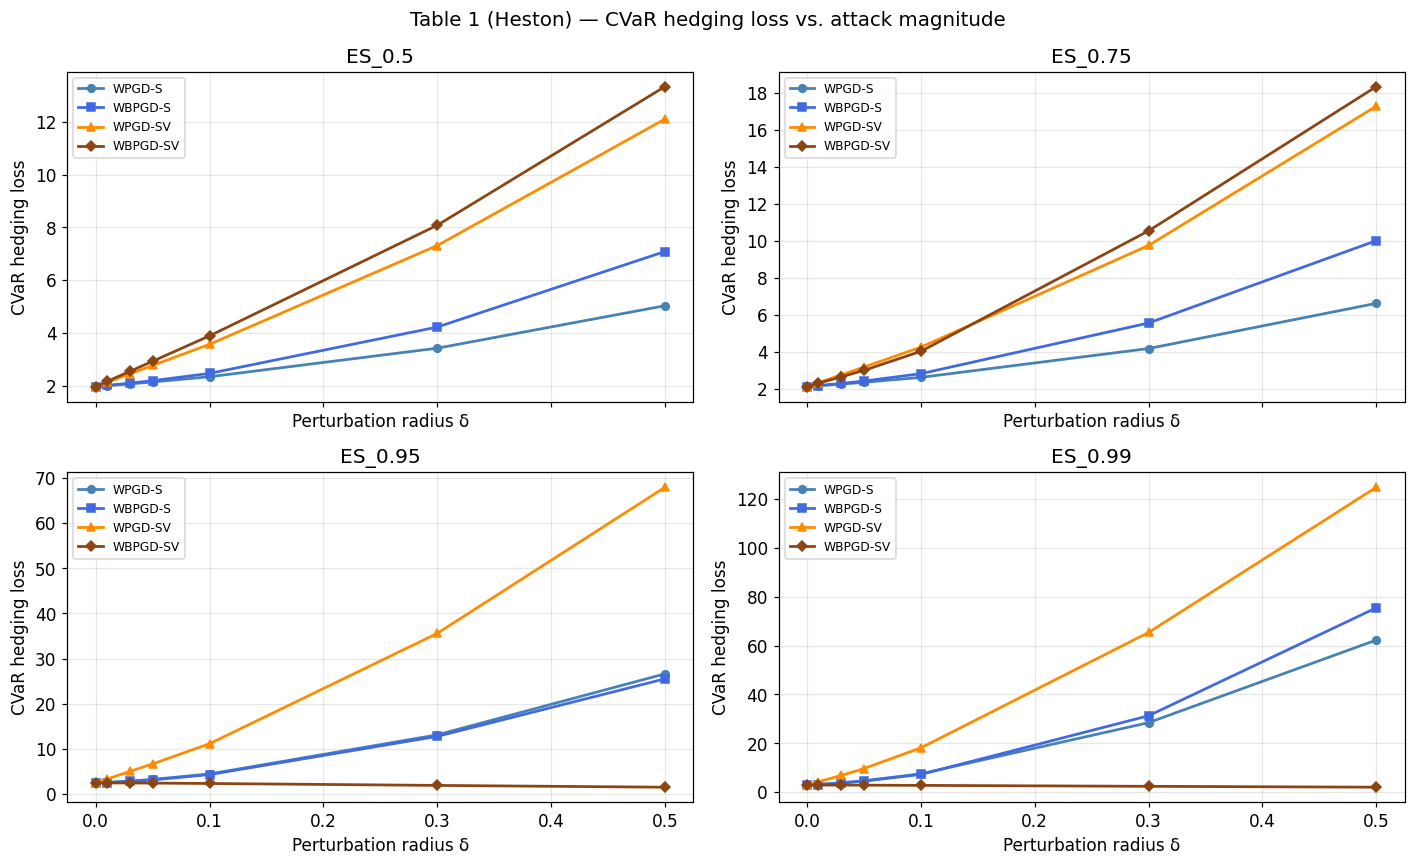

In [9]:
# ---- Figure: CVaR vs perturbation radius ----
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
colors = {'WPGD-S': 'steelblue', 'WBPGD-S': 'royalblue',
          'WPGD-SV': 'darkorange', 'WBPGD-SV': 'saddlebrown'}
markers = {'WPGD-S': 'o', 'WBPGD-S': 's', 'WPGD-SV': '^', 'WBPGD-SV': 'D'}

for ax, alpha in zip(axes.flat, ALPHAS):
    df = all_tables[alpha]
    for col in ['WPGD-S', 'WBPGD-S', 'WPGD-SV', 'WBPGD-SV']:
        ax.plot(df.index, df[col],
                color=colors[col], marker=markers[col],
                linewidth=1.8, markersize=5, label=col)
    ax.set_title(f'ES_{alpha}')
    ax.set_xlabel('Perturbation radius δ')
    ax.set_ylabel('CVaR hedging loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Table 1 (Heston) — CVaR hedging loss vs. attack magnitude', fontsize=13)
plt.tight_layout()
plt.savefig(Path('..') / 'results' / 'heston_table1_attacks.png', bbox_inches='tight')
plt.show()